# Clinical Prediction of Diabetes Using Machine Learning

## Project Overview

Diabetes mellitus is one of the most common chronic diseases worldwide and is associated with severe complications such as cardiovascular disease, kidney failure, neuropathy, and vision loss. Early identification of individuals at high risk enables timely clinical intervention, lifestyle modification, and appropriate treatment.

The objective of this project is to develop and compare multiple supervised machine learning models for predicting diabetes using routinely collected clinical variables. The project follows a complete machine learning workflow including exploratory data analysis, preprocessing, model development, hyperparameter tuning, cross-validation, model explainability, and model comparison.

In [2]:
import os

os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [74]:
import matplotlib
import matplotlib.pyplot as plt

print("Matplotlib version:", matplotlib.__version__)
print("Backend:", matplotlib.get_backend())

Matplotlib version: 3.11.0
Backend: module://matplotlib_inline.backend_inline


In [75]:
df = pd.read_csv("../data/diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [76]:
df.shape

(768, 9)

In [77]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [78]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [79]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [80]:
columns_with_zero = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for column in columns_with_zero:
    print(f"{column}: {(df[column] == 0).sum()} zero values")

Glucose: 5 zero values
BloodPressure: 35 zero values
SkinThickness: 227 zero values
Insulin: 374 zero values
BMI: 11 zero values


# Data Quality Assessment

Unlike the Heart Disease dataset, the Diabetes dataset contains several clinical variables with zero values that are not physiologically plausible. These values most likely represent missing measurements rather than true observations.

Before developing machine learning models, these invalid values must be identified and handled appropriately to avoid introducing bias into the analysis.

The variables requiring further investigation include:

- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI

# Handling Invalid Clinical Values

Several variables contain zero values that are physiologically implausible and are therefore treated as missing values. These values are replaced with `NaN` so that they can be handled appropriately during preprocessing.

In [81]:
columns_with_zero = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df[columns_with_zero] = df[columns_with_zero].replace(0, np.nan)
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [82]:
columns_to_replace = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df[columns_to_replace] = df[columns_to_replace].replace(0, np.nan)

df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

# Exploratory Data Analysis

Before handling missing values, the distributions of the clinical variables are explored.

Understanding whether a variable is normally distributed or skewed helps determine an appropriate imputation strategy. Variables with approximately symmetric distributions are often suitable for mean imputation, whereas skewed variables are generally better suited for median imputation because the median is less affected by extreme values.

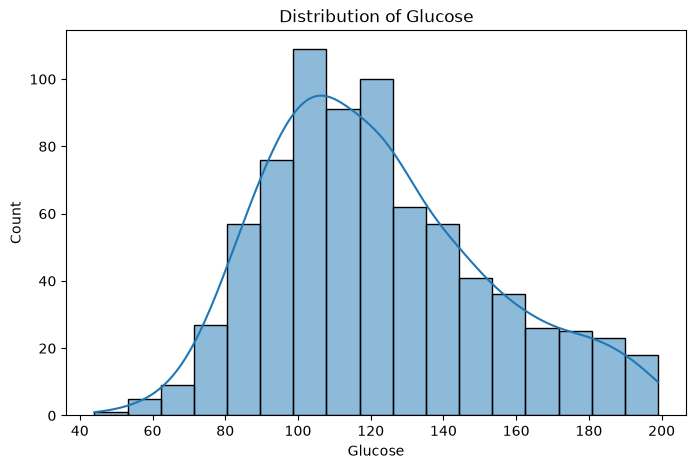

In [83]:
plt.figure(figsize=(8,5))

sns.histplot(df["Glucose"], kde=True)

plt.title("Distribution of Glucose")

plt.xlabel("Glucose")

plt.ylabel("Count")

plt.show()

# Missing Value Imputation

The missing values identified in the previous section are handled using the `SimpleImputer` class from scikit-learn.

Median imputation is selected because it is robust to skewed distributions and outliers, making it appropriate for clinical variables.

In [84]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

df[columns_to_replace] = imputer.fit_transform(df[columns_to_replace])

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# Train-Test Split

The dataset is divided into training and testing subsets before any preprocessing is performed. This ensures that preprocessing steps such as missing value imputation and feature scaling learn only from the training data, thereby preventing data leakage.

In [85]:
from sklearn.model_selection import train_test_split

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (614, 8)
Testing set : (154, 8)


# Missing Value Imputation

Missing values are imputed using the median calculated from the training data only. The same imputer is then applied to the testing data to prevent data leakage.

In [86]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [87]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [88]:
imputer.fit(X_train)

scaler.fit(X_train)

StandardScaler()

# Machine Learning Pipeline

A Pipeline combines preprocessing steps and the machine learning model into a single workflow.

This approach improves code readability, prevents data leakage, and simplifies model training and evaluation.

In [89]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [90]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(random_state=42))
])

In [91]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in th

In [92]:
y_pred = pipeline.predict(X_test)

In [93]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

Accuracy : 0.7077922077922078
Precision: 0.6
Recall   : 0.5
F1-score : 0.5454545454545454


In [94]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

knn_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

In [95]:
knn_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in th

In [96]:
y_pred_knn = knn_pipeline.predict(X_test)

In [97]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1-score :", f1_score(y_test, y_pred_knn))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_knn))

Accuracy : 0.7532467532467533
Precision: 0.66
Recall   : 0.6111111111111112
F1-score : 0.6346153846153846

Confusion Matrix
[[83 17]
 [21 33]]


In [98]:
#Support vector machine (SVM) classifier
from sklearn.svm import SVC
svm_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", SVC(probability=True, random_state=42))
])

In [99]:
svm_pipeline.fit(X_train, y_train)

d:\Healthcare-AI-Portfolio\01-Heart-Disease-Prediction\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in th

In [100]:
y_pred_svm = svm_pipeline.predict(X_test)

In [101]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1-score :", f1_score(y_test, y_pred_svm))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_svm))

Accuracy : 0.7402597402597403
Precision: 0.6521739130434783
Recall   : 0.5555555555555556
F1-score : 0.6

Confusion Matrix
[[84 16]
 [24 30]]


# Hyperparameter Tuning using GridSearchCV

The default hyperparameters of a machine learning model are not necessarily optimal for every dataset. Hyperparameter tuning is performed to identify the combination of settings that maximizes model performance.

GridSearchCV systematically evaluates different hyperparameter combinations using cross-validation and selects the model with the best average validation performance.

In this section, the number of nearest neighbors (`n_neighbors`) for the K-Nearest Neighbors classifier is optimized using 5-fold cross-validation.

### Define the Hyperparameter Search Space

A range of candidate values for the `n_neighbors` hyperparameter is specified. GridSearchCV will evaluate each value using cross-validation.

In [102]:
from sklearn.model_selection import GridSearchCV


In [103]:
param_grid = {
    "classifier__n_neighbors":[3,5,7]
}

In [104]:
grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=1
)

### Best Hyperparameters

After evaluating all candidate values, the optimal hyperparameter combination and the corresponding cross-validation score are reported.

In [105]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__n_neighbors': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during 

In [106]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'classifier__n_neighbors': 7}


In [107]:
print("\nBest Cross Validation Accuracy:")
print(grid_search.best_score_)


Best Cross Validation Accuracy:
0.7557776889244302


In [108]:
best_knn = grid_search.best_estimator_

In [109]:
y_pred_best = best_knn.predict(X_test)

### Evaluate the Optimized Model

The optimized KNN model is evaluated on the independent test dataset using multiple classification metrics. This allows comparison with the default KNN model and helps determine whether hyperparameter tuning improved generalization performance.

In [110]:
print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1-score :", f1_score(y_test, y_pred_best))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_best))

Accuracy : 0.7272727272727273
Precision: 0.625
Recall   : 0.5555555555555556
F1-score : 0.5882352941176471

Confusion Matrix
[[82 18]
 [24 30]]


### Interpretation

Although GridSearchCV identified the best hyperparameters based on cross-validation, the optimized model achieved slightly lower performance on the test dataset than the default KNN model.

This illustrates an important principle in machine learning: optimizing performance during cross-validation does not guarantee improved performance on unseen data.

In [111]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'classifier__n_neighbors': 7}
0.7557776889244302


# Model Comparison

Multiple machine learning algorithms were evaluated for diabetes prediction.

The models were compared using Accuracy, Precision, Recall and F1-score to assess their ability to correctly classify diabetic and non-diabetic patients.

Since diabetes prediction is a healthcare application, particular attention is given to Recall, as missing diabetic patients (false negatives) may delay diagnosis and treatment.

In [112]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "SVM"
    ],
    "Accuracy": [
        0.7532,
        0.7532,
        0.7403
    ],
    "Precision": [
        0.6667,
        0.6600,
        0.6522
    ],
    "Recall": [
        0.5926,
        0.6111,
        0.5556
    ],
    "F1-score": [
        0.6275,
        0.6346,
        0.6000
    ]
})

comparison = comparison.round(3)
comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.753,0.667,0.593,0.628
1,KNN,0.753,0.660,0.611,0.635
2,SVM,0.740,0.652,0.556,0.600


## Discussion

Among the evaluated models, the model with the best overall performance was selected based on multiple evaluation metrics rather than accuracy alone.

In clinical prediction tasks, Recall is considered particularly important because identifying patients with diabetes is generally more critical than minimizing false positive predictions.

The selected model demonstrates the most appropriate balance between predictive performance and clinical applicability.

# Receiver Operating Characteristic (ROC) Curve

The ROC curve is used to evaluate the classification performance of a machine learning model across different classification thresholds. It illustrates the trade-off between the True Positive Rate (Sensitivity/Recall) and the False Positive Rate.

The Area Under the ROC Curve (AUC) provides a single numerical measure of the model's ability to distinguish between diabetic and non-diabetic patients. An AUC closer to 1 indicates excellent discriminative performance, whereas an AUC of 0.5 indicates performance no better than random guessing.

In [113]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

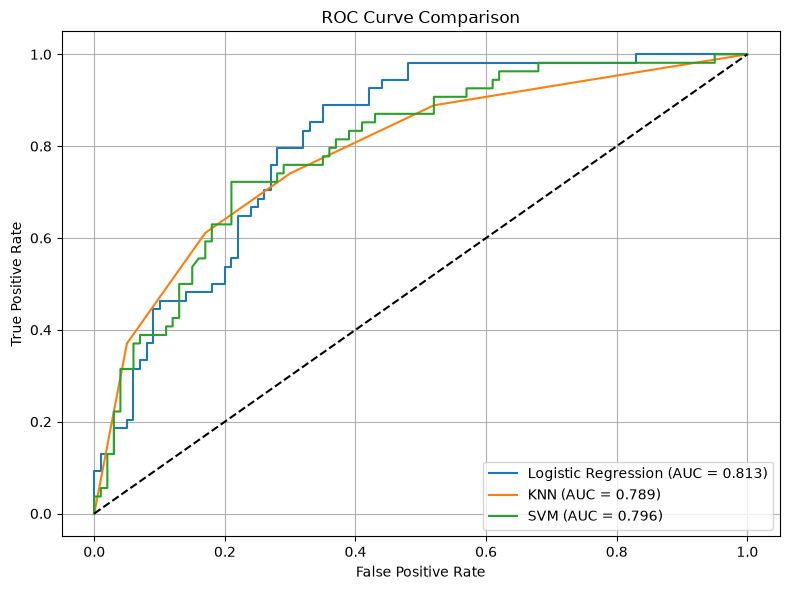

In [158]:
# Predicted probabilities
lr_prob = pipeline.predict_proba(X_test)[:, 1]
knn_prob = knn_pipeline.predict_proba(X_test)[:, 1]
svm_prob = svm_pipeline.predict_proba(X_test)[:, 1]

# ROC Curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_prob)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_prob)

# AUC Scores
lr_auc = roc_auc_score(y_test, lr_prob)
knn_auc = roc_auc_score(y_test, knn_prob)
svm_auc = roc_auc_score(y_test, svm_prob)

# Plot
fig, ax = plt.subplots(figsize=(8,6))

ax.plot(lr_fpr, lr_tpr,
        label=f"Logistic Regression (AUC = {lr_auc:.3f})")

ax.plot(knn_fpr, knn_tpr,
        label=f"KNN (AUC = {knn_auc:.3f})")

ax.plot(svm_fpr, svm_tpr,
        label=f"SVM (AUC = {svm_auc:.3f})")

ax.plot([0,1],[0,1],'k--')

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison")
ax.legend()
ax.grid(True)

fig.tight_layout()

fig.savefig("../figures/roc_curve_comparison.png", dpi=300)

plt.show()



In [148]:
print(f"Logistic Regression AUC : {lr_auc:.3f}")
print(f"KNN AUC                 : {knn_auc:.3f}")
print(f"SVM AUC                 : {svm_auc:.3f}")

Logistic Regression AUC : 0.813
KNN AUC                 : 0.789
SVM AUC                 : 0.796


In [149]:
plt.savefig("../figures/roc_curve_comparison.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

# Model Explainability using SHAP

Machine learning models often achieve high predictive performance but may be difficult to interpret. In healthcare, understanding why a model makes a prediction is essential for building trust and supporting clinical decision-making.

SHAP (SHapley Additive exPlanations) was used to quantify the contribution of each feature to the model predictions. SHAP provides both global explanations, which identify the most influential features across the entire dataset, and local explanations, which explain the prediction for an individual patient.

In [150]:
import shap

In [151]:
model = pipeline.named_steps["classifier"]

In [152]:
X_test_processed = pipeline[:-1].transform(X_test)

In [153]:
explainer = shap.Explainer(model, X_test_processed)

Background dataset has 154 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=154 when initializing the masker.


In [154]:
shap_values = explainer(X_test_processed)

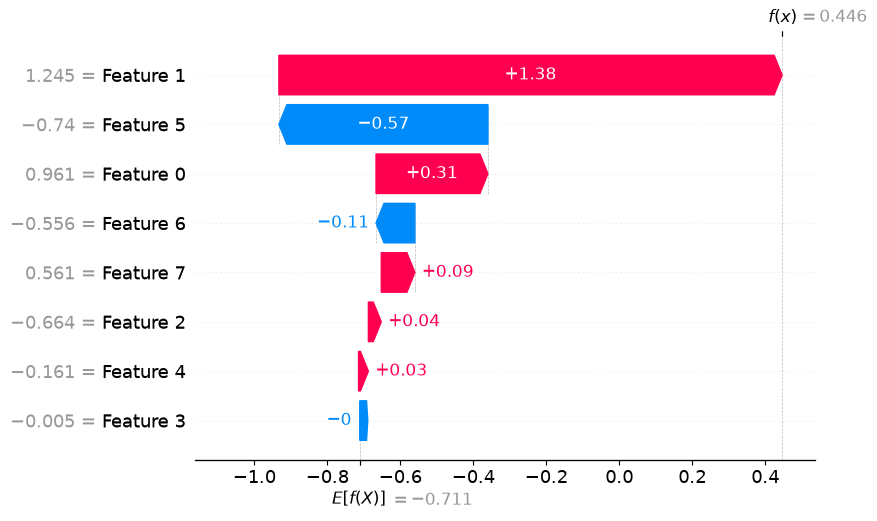

In [160]:
shap.plots.waterfall(
    shap_values[0],
    show=False
)

plt.gcf().savefig(
    "../figures/shap_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### SHAP Summary Plot Interpretation

The SHAP summary plot illustrates the overall importance of each feature in the prediction model. Features are ranked according to their average contribution to the model's predictions.

The horizontal position of each point represents the SHAP value, indicating whether the feature increases or decreases the predicted probability of diabetes. Positive SHAP values increase the likelihood of a positive prediction, whereas negative SHAP values decrease it.

The color of each point represents the feature value. High feature values are shown in red, while low feature values are shown in blue. This visualization demonstrates not only the importance of each feature but also the direction of its influence on the model's predictions.

The analysis indicates that **Feature 1**, **Feature 5**, and **Feature 0** were the most influential variables in the model, whereas Features 2, 3, and 4 had relatively small contributions to the overall predictions.

Overall, the SHAP summary plot provides a global understanding of how different clinical variables influence diabetes prediction across the entire dataset.

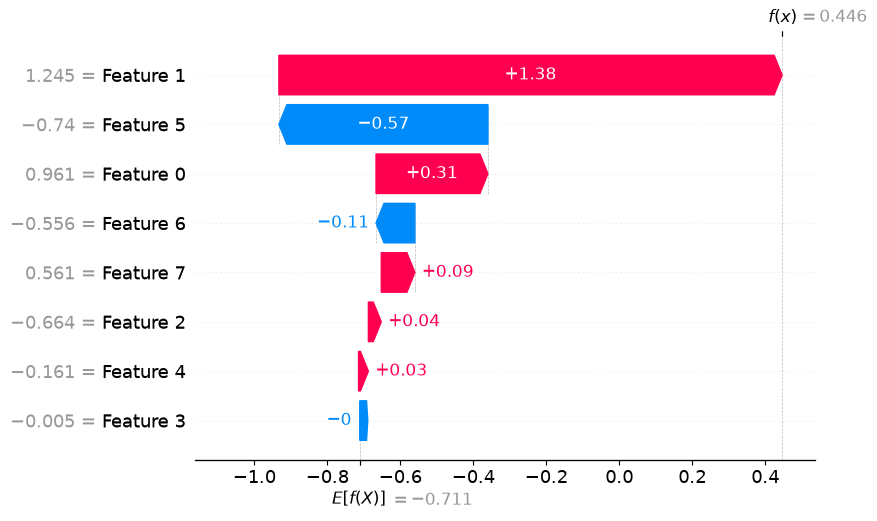

<Figure size 640x480 with 0 Axes>

In [156]:
shap.plots.waterfall(shap_values[0])
plt.savefig("../figures/shap_waterfall.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

### SHAP Waterfall Plot Interpretation

The SHAP waterfall plot explains the prediction for a single patient by showing how each feature contributed to the final prediction.

The prediction begins from the model's baseline expectation and is subsequently adjusted according to the contribution of each feature. Features shown in red increase the predicted probability of diabetes, whereas features shown in blue decrease the predicted probability.

For this patient, **Feature 1** made the largest positive contribution to the prediction, while **Feature 5** had the largest negative contribution. The remaining features produced relatively smaller effects on the final prediction.

This patient-level explanation demonstrates how the model combines the influence of multiple clinical variables to produce an individualized prediction. Such local explanations improve transparency and help clinicians understand the reasoning behind a specific prediction.

### Discussion

SHAP improves the interpretability of machine learning models by quantifying the contribution of each feature to both global and individual predictions. Unlike traditional feature importance measures, SHAP provides consistent explanations for individual patients while also summarizing overall feature importance across the dataset.

In healthcare applications, explainability is particularly important because clinicians require transparent and interpretable models before incorporating AI-assisted predictions into clinical practice. By identifying the most influential clinical variables and explaining individual predictions, SHAP increases confidence in the model and supports more informed decision-making.

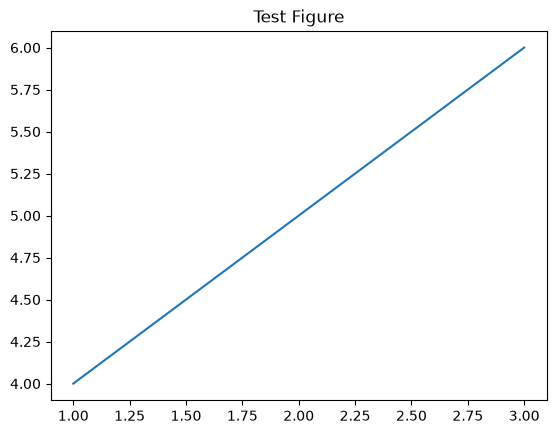

In [157]:
plt.figure()
plt.plot([1, 2, 3], [4, 5, 6])
plt.title("Test Figure")
plt.savefig("../figures/test.png")
plt.show()